In [2]:
import torch
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 1. 가상의 손실 함수를 정의
# x^2 + 10y^2
def loss_func(x, y):
    return x ** 2 + 10 * y ** 2

In [5]:
# 경로 추적 함수
def track_optimizer_path(optimizer_class, start_pos, epochs=50, **kwargs):
    # 파라미터 설정 (x, y 좌표)
    params = torch.tensor(start_pos, requires_grad=True)
    optimizer = optimizer_class([params], **kwargs)

    path = [params.detach().clone().numpy()]

    for _ in range(epochs) :
        optimizer.zero_grad()
        loss = loss_func(params[0], params[1])
        loss.backward()
        optimizer.step()
        path.append(params.detach().clone().numpy())

    return np.array(path)

In [17]:
start_point = [-4.0, 4.0]
epochs = 50
lr = 0.1

# 각 옵티마이저별 경로 계산
path_sgd = track_optimizer_path(optim.SGD, start_point, epochs, lr=lr) # SGD
path_momentum = track_optimizer_path(optim.SGD, start_point, epochs, lr=lr, momentum=0.9) # Momentum
path_adam = track_optimizer_path(optim.Adam, start_point, epochs, lr=lr)

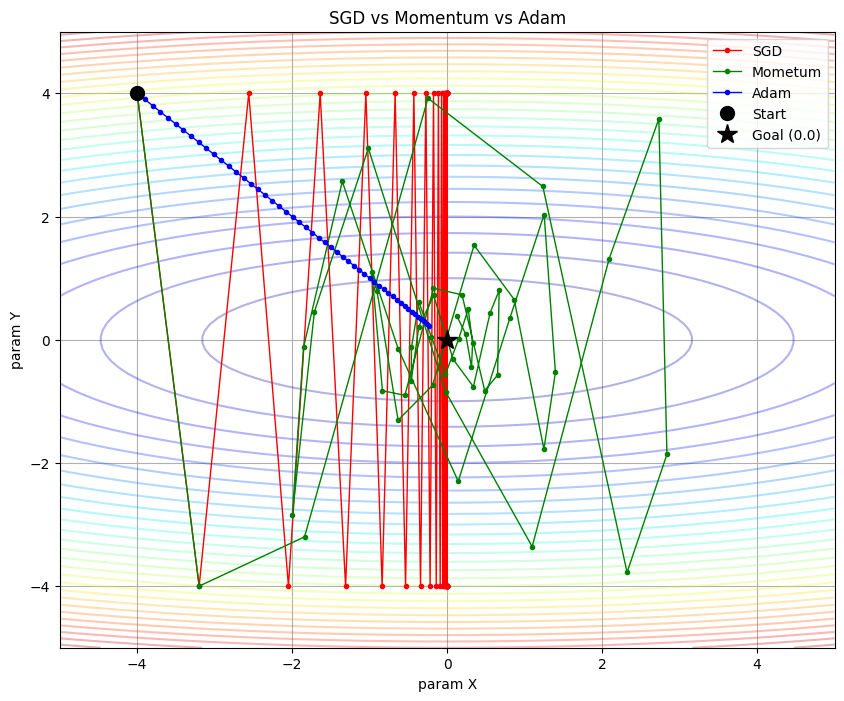

In [18]:
# 시각화
plt.figure(figsize=(10, 8))

# 등고선 그리기
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = X ** 2 + 10 * Y ** 2
plt.contour(X, Y, Z, levels=30, cmap='jet', alpha=0.3)

# 경로 플로팅
plt.plot(path_sgd[:, 0], path_sgd[:, 1], 'ro-', label="SGD", markersize=3, linewidth=1)
plt.plot(path_momentum[:, 0], path_momentum[:, 1], 'go-', label="Mometum", markersize=3, linewidth=1)
plt.plot(path_adam[:, 0], path_adam[:, 1], 'bo-', label="Adam", markersize=3, linewidth=1)

# 시작점과 목표점 표시
plt.plot(start_point[0], start_point[1], 'ko', markersize=10, label='Start')
plt.plot(0, 0, 'k*', markersize=15, label='Goal (0.0)')

plt.title('SGD vs Momentum vs Adam')
plt.xlabel('param X')
plt.ylabel('param Y')
plt.legend()
plt.grid(True)
plt.show()